In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, load_digits
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from scipy.stats import mode
sns.set()

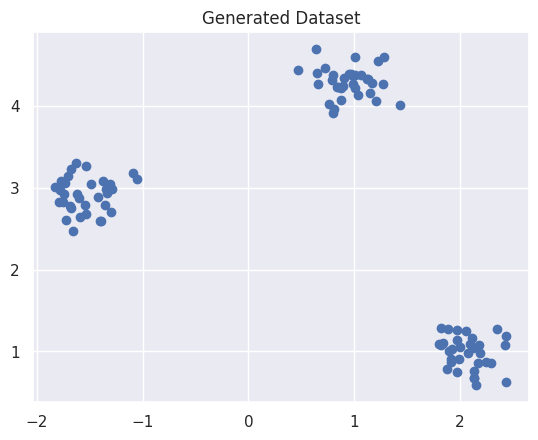

In [7]:
X, _ = make_blobs(n_samples=100, centers=3, n_features=2, cluster_std=0.2, random_state=0)
plt.scatter(X[:,0], X[:,1])
plt.title("Generated Dataset")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X)
centroids = kmeans.cluster_centers_
labels = kmeans.labels_
print("Cluster Centers:")
print(centroids)

Cluster Centers:
[[-1.538563    2.91165191]
 [ 2.0720792   0.98848385]
 [ 0.95164831  4.28882085]]


**Reasoning**:
The previous cell `oTj7o5XkvXKN` has been successfully executed, providing the `labels` and `centroids` variables. Now, to fix the `SyntaxError` in cell `D927binyvXKO` and visualize the K-Means clusters, I need to separate the concatenated plotting statements onto individual lines and then execute the cell.



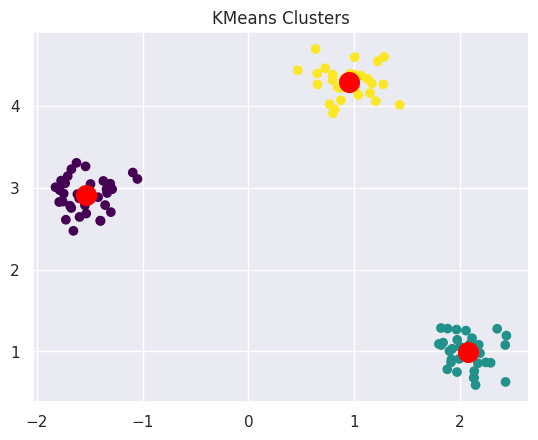

In [11]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], c='red', s=200)
plt.title("KMeans Clusters")
plt.show()

In [12]:
score = silhouette_score(X, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.8816040239688525


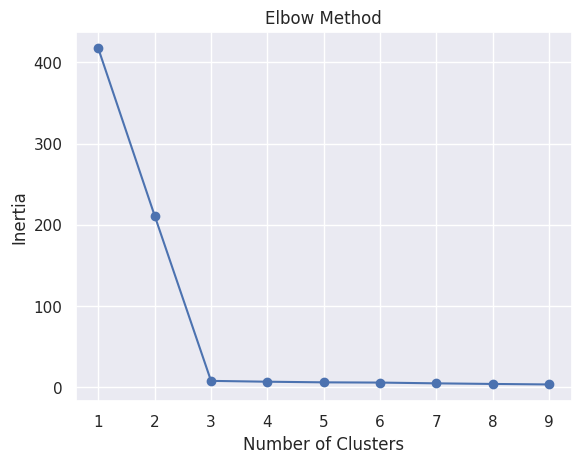

In [13]:
distortions = []
K = range(1,10)
for k in K:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X)
    distortions.append(km.inertia_)
plt.plot(K, distortions, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [14]:
digits = load_digits()
digits_data = digits.data
digits_target = digits.target
print("Shape of digits_data:", digits_data.shape)
print("Shape of digits_target:", digits_target.shape)

Shape of digits_data: (1797, 64)
Shape of digits_target: (1797,)


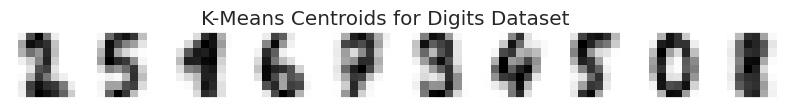

In [16]:
kmeans_digits = KMeans(n_clusters=10, random_state=0, n_init='auto')
kmeans_digits.fit(digits_data)
digits_centroids = kmeans_digits.cluster_centers_

fig, ax = plt.subplots(1, 10, figsize=(10, 1))
for i, centroid in enumerate(digits_centroids):
    ax[i].imshow(centroid.reshape(8, 8), cmap='binary')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.suptitle("K-Means Centroids for Digits Dataset", y=1.05)
plt.show()

Clustering Accuracy: 0.7440


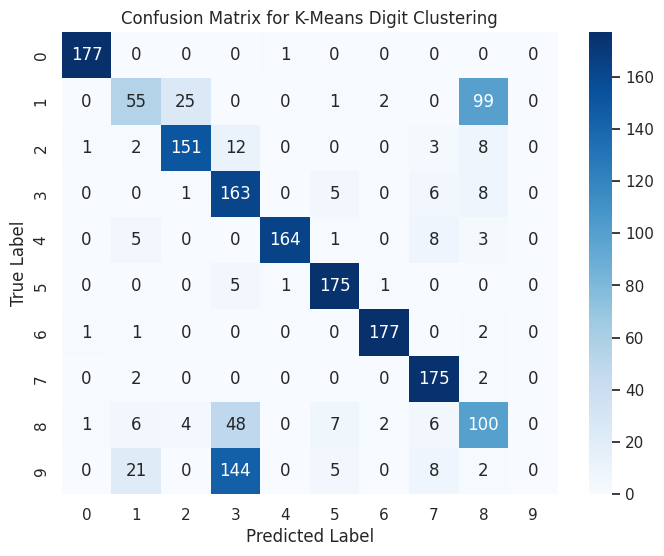

In [19]:
labels_digits = kmeans_digits.labels_

# Map K-Means labels to actual digits
mapped_labels = np.zeros_like(labels_digits)
for i in range(10):
    mask = (labels_digits == i)
    mapped_labels[mask] = mode(digits_target[mask], keepdims=True)[0]

# Calculate accuracy
accuracy = accuracy_score(digits_target, mapped_labels)
print(f"Clustering Accuracy: {accuracy:.4f}")

# Display confusion matrix
cm = confusion_matrix(digits_target, mapped_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for K-Means Digit Clustering')
plt.show()